In [1]:
# ===== Deep SAD (your CSV splits, no synthetic) — using label_pool/unlabeled_pool/val/test =====
import numpy as np, pandas as pd, torch, torch.nn as nn, torch.nn.functional as F
from dataclasses import dataclass
from typing import Optional, Dict
from torch.utils.data import TensorDataset, DataLoader
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix, f1_score, matthews_corrcoef
from sklearn.decomposition import PCA
from inspect import signature
import matplotlib.pyplot as plt
from copy import deepcopy
import time
t0 = time.perf_counter()

# ---------------------------
# 0) Reproducibility
# ---------------------------
SEED = 42
rng = np.random.default_rng(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ---------------------------
# 1) Load CSVs (new protocol)
#    - label_pool.csv: 800 labeled normals + 9 labeled anomalies (Label: 0/1)
#    - unlabeled_pool.csv: all unlabeled samples (Label vẫn giữ để in thống kê nếu có)
#    - val_labeled_40.csv: full validation (Label: 0/1)
#    - Lab_data.csv: full test (Label: 0/1)
# ---------------------------
label_df     = pd.read_csv("label_pool.csv")
unlabeled_df = pd.read_csv("unlabeled_pool.csv")
val_df       = pd.read_csv("val_labeled_40.csv")
test_df      = pd.read_csv("real_data.csv")

# --- DROP các cột thừa nếu có ---
for df in (label_df, unlabeled_df, val_df, test_df):
    for col in ["Unnamed: 0", "Source", "goID"]:
        if col in df.columns:
            df.drop(columns=[col], inplace=True)
# --------------------------------

# Giả sử tất cả các file có cùng tập feature và cột "Label"
FEATURES = [c for c in label_df.columns if c != "Label"]

# Labeled train set (Xl, yl in {+1, -1})
Xl_df  = label_df[FEATURES].copy()
yl_raw = label_df["Label"].to_numpy().astype(int)   # 0=Normal, 1=Anomaly
yl_pm  = np.where(yl_raw == 0, +1, -1)             # +1=Normal, -1=Anomaly (Deep SAD format)

# Unlabeled train set Xu (true labels chỉ để thống kê)
Xu_df = unlabeled_df[FEATURES].copy()
if "Label" in unlabeled_df.columns:
    yu_true = unlabeled_df["Label"].to_numpy().astype(int)
else:
    yu_true = None

# Validation & Test
X_val_df,  y_val_s  = val_df[FEATURES].copy(),  val_df["Label"]
X_test_df, y_test_s = test_df[FEATURES].copy(), test_df["Label"]

# In thống kê giống style cũ
print("=== Deep SAD TRAIN SPLIT (from pre-split CSVs) ===")
print(f"Labeled Xl size           : {len(Xl_df)}")
print(f"  + labeled normals (+1)  : {(yl_pm > 0).sum()}")
print(f"  + labeled anomalies (-1): {(yl_pm < 0).sum()}")
print()
print(f"Unlabeled Xu size         : {len(Xu_df)}")
if yu_true is not None:
    print(f"  + true normals          : {(yu_true == 0).sum()}")
    print(f"  + true anomalies        : {(yu_true == 1).sum()}  (polluted)")
print("========================================================\n")

# ------------------------------------------------
# (Optional) SAVE LABEL POOL CỦA DEEP SAD RA CSV (0=Normal, 1=Anomaly)
# ------------------------------------------------
label_pool_df = Xl_df.copy()
label_pool_df["Label"] = (yl_pm < 0).astype(int)   # 0 = Normal, 1 = Anomaly

label_pool_path = "DeepSAD_label_pool_from_label.csv"
label_pool_df.to_csv(label_pool_path, index=False)

print(f"Saved Deep SAD label pool CSV: {label_pool_path}")
print("Label counts in label pool:", label_pool_df["Label"].value_counts().to_dict())

# ---------------------------
# 3) Preprocess (OneHot categorical + Standardize numeric)
#    Fit ONLY trên Xu ∪ Xl (không đụng VAL/TEST)
# ---------------------------
obj_cols = [
    c for c in Xu_df.columns
    if pd.api.types.is_object_dtype(Xu_df[c]) or pd.api.types.is_categorical_dtype(Xu_df[c])
]
num_cols = [c for c in Xu_df.columns if c not in obj_cols]

# In ra danh sách feature
print("\n==================== FEATURE GROUPS ====================")
print("Categorical (obj_cols):")
for col in obj_cols:
    print("  -", col)

print("\nNumeric (num_cols):")
for col in num_cols:
    print("  -", col)
print("========================================================\n")

# sklearn >=1.4 uses sparse_output
if 'sparse_output' in signature(OneHotEncoder).parameters:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
else:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse=False)

pre = ColumnTransformer(
    transformers=[
        ("cat", ohe, obj_cols),
        ("num", StandardScaler(), num_cols),
    ],
    remainder='drop'
)
pre.fit(pd.concat([Xu_df, Xl_df], axis=0))

def tf(df: pd.DataFrame) -> np.ndarray:
    return pre.transform(df).astype(np.float32)

Xu = tf(Xu_df)
Xl = tf(Xl_df)
Xv = tf(X_val_df)
Xt = tf(X_test_df)

y_val  = y_val_s.to_numpy().astype(np.int64)   # 0=Normal, 1=Anomaly
y_test = y_test_s.to_numpy().astype(np.int64)  # 0=Normal, 1=Anomaly

# Giữ cố định Xu, Xl, yl cho mọi cấu hình (fair across configs)
Xu_fixed = Xu.copy()
Xl_fixed = Xl.copy()
yl_fixed = yl_pm.copy()

# ---------------------------
# 4) Deep SAD model (MLP 2 hidden x 64, latent=8) + AE pretrain
# ---------------------------
@dataclass
class DeepSADConfig:
    hid: int = 64
    zdim: int = 8
    batch_size: int = 100
    weight_decay: float = 1e-3
    lr_search: float = 1e-4
    lr_finetune: float = 1e-5
    epochs_search: int = 50
    epochs_finetune: int = 100
    eta: float = 1.0
    device: str = 'cuda' if torch.cuda.is_available() else 'cpu'
    ae_epochs: int = 50
    ae_lr: float = 1e-3
    dropout: float = 0.0

class Encoder(nn.Module):
    def __init__(self, in_dim: int, hid: int = 64, z: int = 8, p_drop: float = 0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hid), nn.ReLU(),
            nn.Linear(hid, hid), nn.ReLU(),
            nn.Dropout(p_drop),
            nn.Linear(hid, z),
        )
    def forward(self, x):
        return self.net(x)

class Decoder(nn.Module):
    def __init__(self, out_dim: int, hid: int = 64, z: int = 8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z, hid), nn.ReLU(),
            nn.Linear(hid, hid), nn.ReLU(),
            nn.Linear(hid, out_dim),
        )
    def forward(self, z):
        return self.net(z)

class Autoencoder(nn.Module):
    def __init__(self, in_dim: int, hid: int = 64, z: int = 8):
        super().__init__()
        self.encoder = Encoder(in_dim, hid=hid, z=z)
        self.decoder = Decoder(in_dim, hid=hid, z=z)
    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat, z

class DeepSAD:
    def __init__(self, in_dim: int, cfg: DeepSADConfig):
        self.cfg = cfg
        self.encoder = Encoder(in_dim, hid=cfg.hid, z=cfg.zdim).to(cfg.device)
        self.c = torch.zeros(cfg.zdim, device=self.cfg.device)

    def set_center(self, c_vec: torch.Tensor):
        self.c = c_vec.detach().to(self.cfg.device)

    @torch.no_grad()
    def compute_center(self, loader_all_but_labeled_anom: DataLoader):
        self.encoder.eval()
        s = torch.zeros_like(self.c)
        n = 0
        for x in loader_all_but_labeled_anom:
            x = x[0] if isinstance(x, (tuple, list)) else x
            x = x.to(self.cfg.device)
            z = self.encoder(x)
            s += z.sum(0)
            n += z.size(0)
        c = s / max(n, 1)
        c[c.abs() < 1e-6] = 1e-6
        self.set_center(c)
        return c

    def anomaly_score(self, X: torch.Tensor):
        self.encoder.eval()
        with torch.no_grad():
            z = self.encoder(X.to(self.cfg.device))
            return torch.linalg.norm(z - self.c, dim=1)

def _xavier_uniform_linear(m: nn.Module):
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)

def _mk_loader(X: np.ndarray, y: Optional[np.ndarray], bs: int, sh: bool = True) -> DataLoader:
    X_t = torch.from_numpy(X).float()
    if y is None:
        ds = TensorDataset(X_t)
    else:
        ds = TensorDataset(X_t, torch.from_numpy(y).float())
    return DataLoader(ds, batch_size=bs, shuffle=sh, drop_last=False)

def pretrain_ae(X_all: np.ndarray, in_dim: int, cfg: DeepSADConfig) -> Autoencoder:
    ae = Autoencoder(in_dim, hid=cfg.hid, z=cfg.zdim).to(cfg.device)
    ae.apply(_xavier_uniform_linear)
    opt = torch.optim.Adam(ae.parameters(), lr=cfg.ae_lr, weight_decay=cfg.weight_decay)
    loader = _mk_loader(X_all, None, cfg.batch_size, True)
    ae.train()
    for _ in range(cfg.ae_epochs):
        for (xb,) in loader:
            xb = xb.to(cfg.device)
            xh, _ = ae(xb)
            loss = F.mse_loss(xh, xb)
            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()
    return ae

def _deep_sad_loss(zu, zl, yl, c, eta, eps=1e-8):
    du2 = ((zu - c) ** 2).sum(1)
    loss_u = du2.mean() if zu.numel() else torch.tensor(0., device=c.device)
    if zl.numel():
        dl2 = ((zl - c) ** 2).sum(1)
        y = yl.view(-1)
        lp = dl2[y > 0].mean() if (y > 0).any() else torch.tensor(0., device=c.device)
        ln = (1.0 / (dl2[y < 0] + eps)).mean() if (y < 0).any() else torch.tensor(0., device=c.device)
        return loss_u + eta * (lp + ln)
    return loss_u

def train_deepsad(Xu: np.ndarray, Xl: np.ndarray, yl: np.ndarray, cfg: DeepSADConfig) -> Dict:
    in_dim = Xu.shape[1]

    # AE pretrain on all training data (unlabeled + labeled)
    ae = pretrain_ae(np.concatenate([Xu, Xl], axis=0), in_dim, cfg)

    # Init DeepSAD from AE encoder
    model = DeepSAD(in_dim, cfg)
    model.encoder.load_state_dict(ae.encoder.state_dict())

    # Loaders
    ld_u = _mk_loader(Xu, None, cfg.batch_size, True)
    ld_l = _mk_loader(Xl, yl, cfg.batch_size, True)

    # Center on Xu + labeled normals
    X_lab_norm = Xl[yl > 0]
    ld_center = _mk_loader(
        np.concatenate([Xu, X_lab_norm], axis=0),
        None,
        cfg.batch_size,
        False
    )
    _ = model.compute_center(ld_center)

    # Optimizer + two-phase LR schedule
    opt = torch.optim.Adam(
        model.encoder.parameters(),
        lr=cfg.lr_search,
        weight_decay=cfg.weight_decay
    )

    def phase(epochs, lr):
        for g in opt.param_groups:
            g['lr'] = lr
        for _ in range(epochs):
            model.encoder.train()
            it_u, it_l = iter(ld_u), iter(ld_l)
            steps = max(len(ld_u), len(ld_l))
            for _ in range(steps):
                try:
                    xb_u = next(it_u)[0].to(cfg.device)
                except StopIteration:
                    it_u = iter(ld_u)
                    xb_u = next(it_u)[0].to(cfg.device)
                try:
                    xb_l, yb_l = next(it_l)
                    xb_l = xb_l.to(cfg.device)
                    yb_l = yb_l.to(cfg.device)
                except StopIteration:
                    it_l = iter(ld_l)
                    xb_l, yb_l = next(it_l)
                    xb_l = xb_l.to(cfg.device)
                    yb_l = yb_l.to(cfg.device)

                zu = model.encoder(xb_u)
                zl = model.encoder(xb_l)
                loss = _deep_sad_loss(zu, zl, yb_l, model.c, cfg.eta)
                opt.zero_grad(set_to_none=True)
                loss.backward()
                opt.step()

    phase(cfg.epochs_search,  cfg.lr_search)
    phase(cfg.epochs_finetune, cfg.lr_finetune)

    def score_fn(X: np.ndarray, bs: int = 1024) -> np.ndarray:
        loader = _mk_loader(X, None, bs, False)
        ss = []
        model.encoder.eval()
        with torch.no_grad():
            for (xb,) in loader:
                d = model.anomaly_score(xb)
                ss.append(d.cpu().numpy())
        return np.concatenate(ss, axis=0)

    return {
        "encoder": model.encoder,
        "center": model.c.detach().clone(),
        "config": cfg,
        "score_fn": score_fn
    }

# ---------------------------
# 5) Base config (kiến trúc cố định, chỉ tune hyper)
# ---------------------------
cfg_base = DeepSADConfig(
    hid=16,
    zdim=4,
    batch_size=128,
    weight_decay=1e-5,
    lr_search=1e-2,
    lr_finetune=1e-5,
    epochs_search=30,
    epochs_finetune=180,
    eta=1.0,
    ae_epochs=50,
    ae_lr=1e-3,
    dropout=0.0
)

# ---------------------------
# 6) Grid search theo Binary F1(VAL) cho anomaly (tuning q)
# ---------------------------

def tune_q_by_val_f1(scores_val: np.ndarray, y_val: np.ndarray):
    """
    - scores_val: anomaly scores trên toàn bộ VAL
    - y_val: nhãn (0 normal, 1 anomaly)
    - Tuning q trên [0.80, 0.999] để tìm Binary F1 (anomaly class) cao nhất
      + positive class = anomaly (label=1)
    """
    scores_val_norm = scores_val[y_val == 0]

    coarse = np.linspace(0.80, 0.98, 10, endpoint=True)
    fine   = np.linspace(0.98, 0.999, 15, endpoint=True)
    q_grid = np.unique(np.concatenate([coarse, fine]))

    best_f1   = -1.0
    best_q    = None
    best_thr  = None

    for q in q_grid:
        thr = np.percentile(scores_val_norm, q * 100.0)
        y_pred = (scores_val > thr).astype(int)
        # Binary F1 cho anomaly class (pos_label=1)
        f1 = f1_score(y_val, y_pred, average="binary", pos_label=1, zero_division=0)

        if f1 > best_f1:
            best_f1  = f1
            best_q   = q
            best_thr = thr

    return best_f1, best_q, best_thr

search_space = [
    {"eta": 1.0, "ae_epochs": 50,  "lr_search": 1e-4, "lr_finetune": 1e-5},
    # có thể thêm cấu hình khác nếu muốn
]

best = None
results = []

for i, hp in enumerate(search_space, 1):
    cfg = deepcopy(cfg_base)
    cfg.eta         = hp["eta"]
    cfg.ae_epochs   = hp["ae_epochs"]
    cfg.lr_search   = hp["lr_search"]
    cfg.lr_finetune = hp["lr_finetune"]

    print(f"[{i}/{len(search_space)}] Try "
          f"eta={cfg.eta} | ae_epochs={cfg.ae_epochs} | "
          f"lr={cfg.lr_search}->{cfg.lr_finetune}")

    out_i = train_deepsad(Xu_fixed, Xl_fixed, yl_fixed, cfg)

    # scores trên VAL
    scores_val_i = out_i["score_fn"](Xv)
    # tuning q theo Binary F1(anomaly) trên VAL
    val_f1_i, q_i, thr_i = tune_q_by_val_f1(scores_val_i, y_val)

    results.append((val_f1_i, hp, out_i, q_i, thr_i))
    print(f"  -> VAL F1_binary(anomaly) = {val_f1_i:.5f} at q={q_i:.4f}, thr={thr_i:.6f}")

    if (best is None) or (val_f1_i > best[0]):
        best = (val_f1_i, hp, out_i, q_i, thr_i)

# Summary (sắp xếp theo VAL Binary F1 anomaly)
results_sorted = sorted(results, key=lambda t: t[0], reverse=True)
print("\n=== Grid search results (VAL Binary F1 for anomaly class) ===")
for rank, (f1v, hpo, _, qv, thrv) in enumerate(results_sorted, 1):
    print(f"{rank:>2}. F1_VAL_binary(anomaly)={f1v:.5f} | "
          f"eta={hpo['eta']} | ae_epochs={hpo['ae_epochs']} | "
          f"lr={hpo['lr_search']}->{hpo['lr_finetune']} | "
          f"q*={qv:.4f} | thr*={thrv:.6f}")

best_val_f1, best_cfg_over, best_out, best_q, best_thr = best
print("\n>>> BEST by VAL Binary F1 (anomaly class):", f"{best_val_f1:.5f}",
      "| cfg:", best_cfg_over,
      "| q*=", f"{best_q:.4f}",
      "| thr*=", f"{best_thr:.6f}")
# ---- TRAIN ----

# ---------------------------
# 7) Đánh giá trên TEST với model & threshold tốt nhất (VAL Binary F1 anomaly)
# ---------------------------
best_score_fn = best_out["score_fn"]

# =========================
# TRAIN anomaly scores
# =========================
best_score_fn = best_out["score_fn"]

# Labeled TRAIN
scores_Xl = best_score_fn(Xl_fixed)   # (N_labeled,)
yl_pm     = yl_fixed                  # +1 normal, -1 anomaly

# Unlabeled TRAIN
scores_Xu = best_score_fn(Xu_fixed)   # (N_unlabeled,)

print("Scores computed:")
print("  scores_Xl:", scores_Xl.shape)
print("  scores_Xu:", scores_Xu.shape)

t1 = time.perf_counter()
scores_test = best_score_fn(Xt)
y_pred_test = (scores_test > best_thr).astype(int)

# Binary F1 cho anomaly class trên TEST
test_f1_anom = f1_score(y_test, y_pred_test, average="binary", pos_label=1, zero_division=0)
test_auroc   = roc_auc_score(y_test, scores_test)

# MCC trên TEST
test_mcc = matthews_corrcoef(y_test, y_pred_test)
# ---- TEST ----
t2 = time.perf_counter()
print("\n=== TEST metrics (chosen by best VAL Binary F1 for anomaly) ===")
print(f"AUROC_test                      : {test_auroc:.5f}")
print(f"F1_binary(anomaly class)_test   : {test_f1_anom:.5f}")
print(f"MCC_test                        : {test_mcc:.5f}")

cm = confusion_matrix(y_test, y_pred_test)
def format_time(seconds):
    minutes = int(seconds // 60)
    secs = seconds % 60
    return f"{minutes:d} min {secs:05.2f} s"
print("Confusion matrix (rows=true, cols=pred):\n", cm)
print(f"Training time   : {format_time(t1 - t0)}")
print(f"Testing time : {format_time(t2 - t1)}")

=== Deep SAD TRAIN SPLIT (from pre-split CSVs) ===
Labeled Xl size           : 809
  + labeled normals (+1)  : 800
  + labeled anomalies (-1): 9

Unlabeled Xu size         : 31341
  + true normals          : 21000
  + true anomalies        : 10341  (polluted)

Saved Deep SAD label pool CSV: DeepSAD_label_pool_from_label.csv
Label counts in label pool: {0: 800, 1: 9}

==================== FEATURE GROUPS ====================
Categorical (obj_cols):

Numeric (num_cols):
  - Length
  - stNum
  - sqNum
  - heartbeat
  - dif_stNum
  - dif_sqNum
  - Circuit breaker Open/Close Status
  - I-high VT
  - I-high VT- Tran
  - I-low VT- Tran
  - I-amongst-feeders

[1/1] Try eta=1.0 | ae_epochs=50 | lr=0.0001->1e-05


/tmp/ipykernel_47626/3957320434.py:97: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_object_dtype(Xu_df[c]) or pd.api.types.is_categorical_dtype(Xu_df[c])


  -> VAL F1_binary(anomaly) = 0.87719 at q=0.9990, thr=0.449315

=== Grid search results (VAL Binary F1 for anomaly class) ===
 1. F1_VAL_binary(anomaly)=0.87719 | eta=1.0 | ae_epochs=50 | lr=0.0001->1e-05 | q*=0.9990 | thr*=0.449315

>>> BEST by VAL Binary F1 (anomaly class): 0.87719 | cfg: {'eta': 1.0, 'ae_epochs': 50, 'lr_search': 0.0001, 'lr_finetune': 1e-05} | q*= 0.9990 | thr*= 0.449315
Scores computed:
  scores_Xl: (809,)
  scores_Xu: (31341,)

=== TEST metrics (chosen by best VAL Binary F1 for anomaly) ===
AUROC_test                      : 0.21627
F1_binary(anomaly class)_test   : 0.50909
MCC_test                        : 0.00000
Confusion matrix (rows=true, cols=pred):
 [[ 0 54]
 [ 0 28]]
Training time   : 2 min 22.04 s
Testing time : 0 min 00.00 s


In [2]:

# ---------------------------
# 7) Evaluate on TEST using best model + q* từ VAL F1
# ---------------------------
thr_best = best_thr
scores_test_best = best_out["score_fn"](Xt)

test_auc_best = roc_auc_score(y_test, scores_test_best)
test_ap_best  = average_precision_score(y_test, scores_test_best)
y_pred_best   = (scores_test_best > thr_best).astype(int)
cm_best       = confusion_matrix(y_test, y_pred_best, labels=[0, 1])
f1_test       = f1_score(y_test, y_pred_best, zero_division=0)

print("\n=== BEST MODEL EVAL ON TEST (q tuned by VAL F1) ===")
print(f"q* (from VAL)    : {best_q:.4f}")
print(f"Threshold (TEST) : {thr_best:.6f}")
print(f"Test AUROC       : {test_auc_best:.4f}")
print(f"Test AUPRC       : {test_ap_best:.4f}")
print(f"Test F1          : {f1_test:.4f}")
print("Confusion matrix TEST (rows=true [0 normal,1 anomaly], cols=pred [0,1]):\n",
      cm_best)




=== BEST MODEL EVAL ON TEST (q tuned by VAL F1) ===
q* (from VAL)    : 0.9990
Threshold (TEST) : 0.449315
Test AUROC       : 0.2163
Test AUPRC       : 0.2314
Test F1          : 0.5091
Confusion matrix TEST (rows=true [0 normal,1 anomaly], cols=pred [0,1]):
 [[ 0 54]
 [ 0 28]]


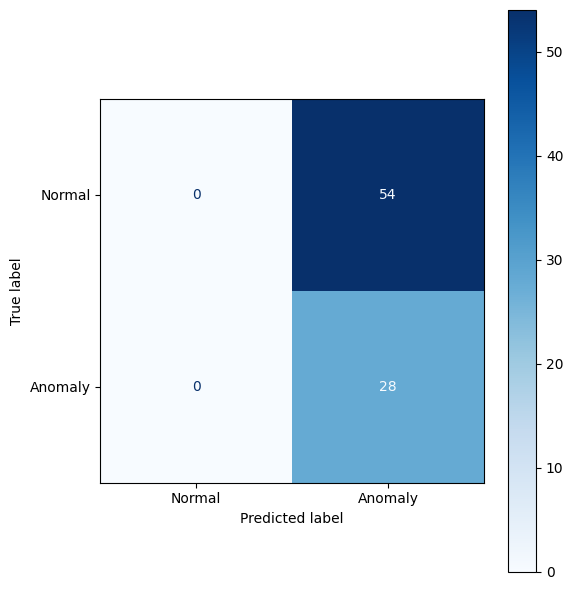

In [3]:
from sklearn.metrics import ( roc_auc_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, )
# --------- VẼ CONFUSION MATRIX (Deep SAD) ----------
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_best,
    display_labels=["Normal", "Anomaly"]
)
fig_cm, ax_cm = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax_cm, cmap="Blues", colorbar=True)
plt.title("")
plt.tight_layout()
plt.savefig("confusion_matrix_DEEP SAD.png", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
# ============================================================
# 8) Monitoring-style chart with color-coded Normal / Abnormal
#    - NO fault occurrence time
#    - Color by ground-truth label (TEST only, for visualization)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, LogFormatterMathtext

def plot_monitoring_chart_colored(scores, labels, thr, title, out_png):
    scores = np.asarray(scores).reshape(-1)
    labels = np.asarray(labels).reshape(-1)
    x = np.arange(len(scores))

    # tránh log(0)
    eps = 1e-12
    scores_plot = scores.copy()
    scores_plot[scores_plot <= 0] = eps
    thr_plot = max(thr, eps)

    mask_norm = (labels == 0)
    mask_anom = (labels == 1)

    plt.figure(figsize=(7, 5))

    plt.scatter(x[mask_norm], scores_plot[mask_norm], s=8, label="Normal")
    plt.scatter(x[mask_anom], scores_plot[mask_anom], s=8, label="Abnormal")
    plt.axhline(thr_plot, linewidth=2, color="red", label="Threshold")

    # ==== TRỤC Y LOG TỪ 1e-11 ĐẾN 1e4 ====
    plt.yscale("log")
    plt.ylim(1e-11, 1e4)

    ax = plt.gca()
    ax.yaxis.set_major_locator(LogLocator(base=10.0))
    ax.yaxis.set_major_formatter(LogFormatterMathtext())
    ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1))

    plt.xlabel("Sample point")
    plt.ylabel("Anomaly Score")
    plt.title(title)

    # Legend bên trái
    plt.legend(loc="lower left", frameon=False)

    plt.grid(False)
    plt.tight_layout()
    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.show()

plot_monitoring_chart_colored(
    scores=scores_test,
    labels=y_test,   # 0 = Normal, 1 = Abnormal
    thr=best_thr,
    title="",
    out_png="MonitoringChart_Deep SAD.png"
)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# REQUIRE (đã có từ pipeline của bạn):
#   scores_Xl : anomaly scores của LABELED TRAIN
#   yl_pm     : nhãn Deep SAD (+1 = normal, -1 = anomaly)
# =====================================================

# --- Split labeled train ---
scores_normal  = scores_Xl[yl_pm > 0]   # labeled normal
scores_anomaly = scores_Xl[yl_pm < 0]   # labeled anomaly

print("TRAIN labeled normal :", len(scores_normal))
print("TRAIN labeled anomaly:", len(scores_anomaly))

if len(scores_normal) == 0 or len(scores_anomaly) == 0:
    raise ValueError("Thiếu normal hoặc anomaly trong labeled train.")

# --- Min / Max ---
n_min, n_max = float(np.min(scores_normal)),  float(np.max(scores_normal))
a_min, a_max = float(np.min(scores_anomaly)), float(np.max(scores_anomaly))

plt.figure(figsize=(7, 6))

# --- Axis (giữ như bạn) ---
plt.yscale("log")
plt.ylim(1e-3, 1e2)
plt.xlim(0, 20)

# --- Histogram filled ---
plt.hist(scores_normal, bins=40, density=True, alpha=0.6, label="Normal")
plt.hist(scores_anomaly, bins=40, density=True, alpha=0.6, label="Anomaly")

# --- Histogram outline (như bạn) ---
plt.hist(scores_normal, bins=40, density=True,
         histtype="step", linewidth=1.5, color="#1f77b4")

# --- Marker X tại min / max (log-scale không vẽ được y=0) ---
y_marker = 1e-3
plt.scatter([n_min, n_max], [y_marker, y_marker],
            s=30, marker="X", linewidths=0.8,
            zorder=10, color="#1f77b4", clip_on=False)

plt.scatter([a_min, a_max], [y_marker, y_marker],
            s=30, marker="X", linewidths=0.8,
            zorder=10, color="#ff7f0e", clip_on=False)

# --- Text dưới trục X (KHÔNG đè lên hình, an toàn cho log-scale) ---
ax = plt.gca()
y_offset = -0.23  # chỉnh -0.18 ~ -0.30 nếu muốn gần/xa hơn

ax.text(n_min-0.1
        , y_offset, f"Min(Normal)={n_min:.2f}",
        transform=ax.get_xaxis_transform(),
        ha="center", va="top", fontsize=9.5, rotation=90, clip_on=False)

ax.text(n_max+0.1, y_offset, f"Max(Normal)={n_max:.2f}",
        transform=ax.get_xaxis_transform(),
        ha="center", va="top", fontsize=9.5, rotation=90, clip_on=False)

ax.text(a_min, y_offset, f"Min(Anomaly)={a_min:.2f}",
        transform=ax.get_xaxis_transform(),
        ha="center", va="top", fontsize=9.5, rotation=90, clip_on=False)

ax.text(a_max, y_offset, f"Max(Anomaly)={a_max:.2f}",
        transform=ax.get_xaxis_transform(),
        ha="center", va="top", fontsize=9.5, rotation=90, clip_on=False)
plt.grid(True)
# --- Style (giữ giống cũ, KHÔNG grid) ---
plt.xlabel("Anomaly Score")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()

# --- Save ---
plt.savefig("DeepSAD_score_histogram_labeled_minmax.png",
            dpi=300, bbox_inches="tight")
plt.show()

print("Saved: DeepSAD_score_histogram_labeled_minmax.png")


In [ ]:
counts_n, bins_n = np.histogram(scores_normal, bins=40, density=True)
print("Max normal density:", counts_n.max())